## Assignment2 / Applying ML Algorithms
## Sahar Mohammad Ghanem 
## 2320221077

## Import Libraries
## Explanation:

### In this cell, I imported the required libraries for data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

## Load Marketing Campaign Dataset
## Explanation:

### I loaded the marketing campaign dataset using pandas and specified tab as the separator.

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Display Dataset Shape
## Explanation

### I displayed the number of rows and columns in the dataset.

In [3]:
print(df.shape)

(2240, 29)


## Dataset Information
## Explanation:

### I displayed the dataset information including data types and non-null values.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Check Missing Values
## Explanation:

### I checked for missing values in the dataset.

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## Handle Missing Values
## Explanation:

### I filled missing Income values using median imputation.

In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())

## Verify Missing Values
## Explanation

### I verified that all missing values were successfully handled.

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

## Feature Engineering – Age
## Explanation

### I created a new Age feature based on the birth year.

In [8]:
current_year = 2026
df['Age'] = current_year - df['Year_Birth']

## Feature Engineering – Total Spending
## Explanation

### I created the TotalSpending feature by summing all spending-related columns.

In [9]:
df['TotalSpending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

## Feature Engineering – Total Children
## Explanation:

### I created the TotalChildren feature by combining Kidhome and Teenhome.


In [10]:
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']

## Data Filtering
## Explanation:

### I removed unrealistic ages and customers with zero income.

In [11]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]
df = df[df['Income'] > 0]

## Label Encoding for Education
## Explanation:

### I encoded education levels into numerical values using label encoding.

In [12]:
education_map = {
    'Basic': 0,
    'Graduation': 1,
    'Master': 2,
    'PhD': 3,
    '2n Cycle': 1
}

df['Education'] = df['Education'].map(education_map)

## Group Marital Status Categories
## Explanation:

### I kept the top four marital status categories and grouped the rest into Other.

In [13]:
top_categories = df['Marital_Status'].value_counts().nlargest(4).index

df['Marital_Status'] = df['Marital_Status'].apply(
    lambda x: x if x in top_categories else 'Other'
)

## One-Hot Encoding
## Explanation:

### I applied One-Hot Encoding to the marital status feature.

In [14]:
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

## Processed Dataset Preview
## Explanation:

### I displayed the processed dataset after preprocessing and feature engineering.

In [15]:
df.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,TotalChildren,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together
0,5524,1957,1,58138.0,0,0,04-09-2012,58,635,88,...,3,11,1,69,1617,0,0,0,1,0
1,2174,1954,1,46344.0,1,1,08-03-2014,38,11,1,...,3,11,0,72,27,2,0,0,1,0
2,4141,1965,1,71613.0,0,0,21-08-2013,26,426,49,...,3,11,0,61,776,0,0,0,0,1
3,6182,1984,1,26646.0,1,0,10-02-2014,26,11,4,...,3,11,0,42,53,1,0,0,0,1
4,5324,1981,3,58293.0,1,0,19-01-2014,94,173,43,...,3,11,0,45,422,1,1,0,0,0


## PART 2 — Supervised Learning (Regression)

## Define Features and Target
## Explanation:
### I separated the target variable from the input features.

In [16]:
X = df.drop('TotalSpending', axis=1)

y = df['TotalSpending']

## Select Numeric Features
## Explanation:
### I selected only numeric features for modeling.

In [17]:
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

## Train-Test Split
## Explanation:
### I split the dataset into training and testing sets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Feature Scaling
## Explanation:
### I standardized the feature values using StandardScaler.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Train Linear Regression
## Explanation:
### I trained a Linear Regression model.

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

## Linear Regression Prediction
## Explanation:
### I generated predictions using the Linear Regression model.

In [52]:
lr_pred = lr.predict(X_test_scaled)

## Evaluate Linear Regression
## Explanation:
### I evaluated the model using MSE, RMSE, and R² score.

In [22]:
lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

MSE: 3.583646335791215e-25
RMSE: 5.986356434252153e-13
R2: 1.0


## Train Ridge Regression
## Explanation:
### I trained a Ridge Regression model to reduce overfitting.

In [23]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

Ridge()

## Ridge Predictions
## Explanation:
### I generated predictions using the Ridge model.

In [24]:
ridge_pred = ridge.predict(X_test_scaled)

## Evaluate Ridge Regression
### Explanation:
### I evaluated the Ridge Regression model.

In [25]:
ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2:", ridge_r2)

MSE: 0.1660736462419846
RMSE: 0.40752134452318517
R2: 0.9999995628193535


## Train Decision Tree Regressor
## Explanation:
### I trained a Decision Tree Regressor model.

In [26]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

## Decision Tree Predictions
## Explanation:
### I generated predictions using the Decision Tree model.

In [27]:
dt_pred = dt.predict(X_test)

## Evaluate Decision Tree
## Explanation:
### I evaluated the Decision Tree model.

In [28]:
dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_pred)

print("MSE:", dt_mse)
print("RMSE:", dt_rmse)
print("R2:", dt_r2)

MSE: 16263.420996388557
RMSE: 127.52811845388669
R2: 0.9571873499200718


## Regression Models Comparison
## Explanation:
### I compared the performance of the three regression models.

In [29]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Decision Tree'
    ],
    'MSE': [
        lr_mse,
        ridge_mse,
        dt_mse
    ],
    'RMSE': [
        lr_rmse,
        ridge_rmse,
        dt_rmse
    ],
    'R2': [
        lr_r2,
        ridge_r2,
        dt_r2
    ]
})

comparison

,Model,MSE,RMSE,R2
0,Linear Regression,3.583646e-25,5.986356e-13,1.000000
1,Ridge Regression,1.660736e-01,4.075213e-01,1.000000
2,Decision Tree,1.626342e+04,1.275281e+02,0.957187


## PART 3 — Classification

## Class Distribution
## Explanation:
### I examined the class distribution of the target variable.

In [31]:
df['Response'].value_counts()

0    1903
1     334
Name: Response, dtype: int64

## Define Classification Features and Target
## Explanation:
### I separated the classification target from the features.

In [32]:
X_cls = df.drop('Response', axis=1)

y_cls = df['Response']

## Select Numeric Features
## Explanation:
### I selected numeric features only.

In [33]:
X_cls = X_cls.select_dtypes(include=['int64','float64','bool'])

## Train-Test Split
## Explanation:
### I split the classification dataset into training and testing sets.

In [34]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

## Feature Scaling
## Explanation:
### I standardized the feature values

In [35]:
scaler_cls = StandardScaler()

X_train_c = scaler_cls.fit_transform(X_train_c)

X_test_c = scaler_cls.transform(X_test_c)

## Train Logistic Regression
## Explanation:
### I trained a Logistic Regression model.

In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_c, y_train_c)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Logistic Regression Predictions
## Explanation:
### I generated predictions using Logistic Regression.

In [37]:
log_pred = log_model.predict(X_test_c)

## Evaluate Logistic Regression
## Explanation:
### I evaluated the Logistic Regression model

In [38]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test_c, log_pred))
print("Precision:", precision_score(y_test_c, log_pred))
print("Recall:", recall_score(y_test_c, log_pred))
print("F1:", f1_score(y_test_c, log_pred))

print(confusion_matrix(y_test_c, log_pred))

Accuracy: 0.8147321428571429
Precision: 0.4322033898305085
Recall: 0.7611940298507462
F1: 0.5513513513513514
[[314  67]
 [ 16  51]]


## Train KNN Model
### Explanation:
### I trained a KNN classifier.

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_c, y_train_c)

knn_pred = knn.predict(X_test_c)

## Evaluate KNN
## Explanation:
### I evaluated the KNN model.

In [40]:
print("Accuracy:", accuracy_score(y_test_c, knn_pred))
print("Precision:", precision_score(y_test_c, knn_pred))
print("Recall:", recall_score(y_test_c, knn_pred))
print("F1:", f1_score(y_test_c, knn_pred))

print(confusion_matrix(y_test_c, knn_pred))

Accuracy: 0.8660714285714286
Precision: 0.6060606060606061
Recall: 0.29850746268656714
F1: 0.39999999999999997
[[368  13]
 [ 47  20]]


## Train Random Forest
## Explanation:
### I trained a Random Forest classifier.

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_c, y_train_c)

rf_pred = rf.predict(X_test_c)

## Evaluate Random Forest
## Explanation:
### I evaluated the Random Forest model.

In [42]:
print("Accuracy:", accuracy_score(y_test_c, rf_pred))
print("Precision:", precision_score(y_test_c, rf_pred))
print("Recall:", recall_score(y_test_c, rf_pred))
print("F1:", f1_score(y_test_c, rf_pred))

print(confusion_matrix(y_test_c, rf_pred))

Accuracy: 0.8705357142857143
Precision: 0.6451612903225806
Recall: 0.29850746268656714
F1: 0.4081632653061224
[[370  11]
 [ 47  20]]


## Classification Comparison
## Explanation:
### I compared the classification models.

In [43]:
classification_results = pd.DataFrame({
    'Model':['Logistic Regression','KNN','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test_c,log_pred),
        accuracy_score(y_test_c,knn_pred),
        accuracy_score(y_test_c,rf_pred)
    ],
    'F1 Score':[
        f1_score(y_test_c,log_pred),
        f1_score(y_test_c,knn_pred),
        f1_score(y_test_c,rf_pred)
    ]
})

classification_results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.814732,0.551351
1,KNN,0.866071,0.400000
2,Random Forest,0.870536,0.408163


## PART 4 — Clustering

## Select Clustering Features
## Explanation:
### I selected the features used for clustering.

In [44]:
cluster_features = df[
    ['TotalSpending',
     'Income',
     'Age',
     'TotalChildren']
]

## Scale Clustering Data
## Explanation:
### I standardized the clustering features.

In [45]:
cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_features)

## Elbow Method
## Explanation:
### I calculated inertia values for different numbers of cluster

In [46]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

## Plot Elbow Curve
## Explanation:
### I visualized the Elbow Method results.

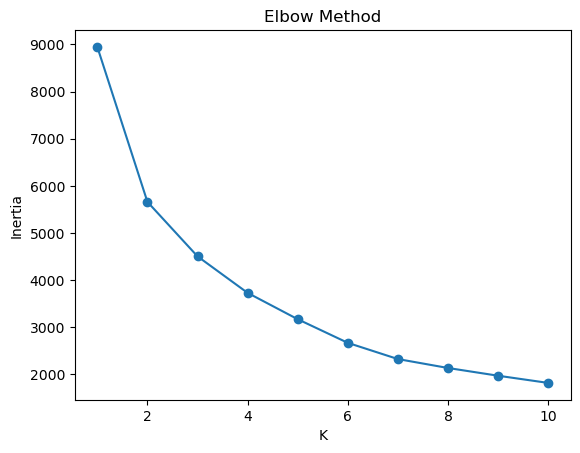

In [47]:
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## Apply K-Means
## Explanation:
### I applied K-Means clustering.

In [48]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(cluster_scaled)

## PCA Dimensionality Reduction
## Explanation:
### I applied PCA for dimensionality reduction.

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(cluster_scaled)

## Visualize Clusters
## Explanation:
### I visualized the clusters using a scatter plot.

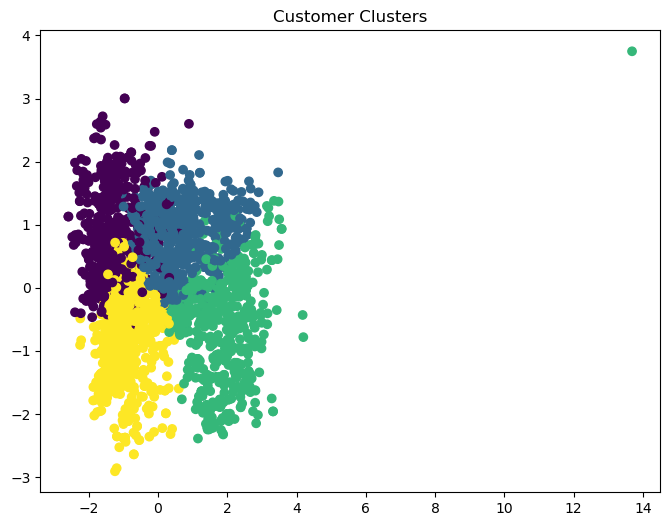

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=df['Cluster']
)

plt.title("Customer Clusters")

plt.show()

## Cluster Profiling
## Explanation:
### I analyzed the average characteristics of each cluster.

In [51]:
cluster_profile = df.groupby('Cluster')[
    ['Income',
     'TotalSpending',
     'Age',
     'TotalChildren']
].mean()

cluster_profile

,Income,TotalSpending,Age,TotalChildren
Cluster,,,,
0,44108.534934,222.812227,60.589520,2.115721
1,61336.053082,802.909247,69.142123,0.688356
2,78094.845572,1434.786177,51.498920,0.285097
3,33678.734290,163.654372,48.846995,0.852459


## Cluster Interpretation
##  I interpreted the customer clusters based on their profiles
## -----

## Cluster Interpretation

### Cluster 0: High income and high spending customers.

### Cluster 1: Medium income customers with moderate spending.

### Cluster 2: Low income and low spending customers.

### Cluster 3: Customers with larger families and different spending behavior.